# RetinaVLM Meta Init Inference Pipeline (방법 3)

Base Llama3를 `from_config`로 빈 껍데기만 생성한 뒤, HF 8-bit 체크포인트를 역양자화하여 직접 `load_state_dict`하는 방식.

**기존 방식 대비 장점:**
- Base Llama3 이중 로드 없음 (메모리 절약)
- `save_pretrained()` 직렬화 문제 회피 (DictConfig, set, tied weights)
- 중간 `model.pt` 저장 불필요 — HF 캐시에서 직접 로드

**흐름:**
1. Hydra config 초기화
2. RetinaVLM 빈 모델 생성 (initialize=False)
3. HF 체크포인트 다운로드 + int8→fp16 역양자화
4. load_state_dict로 가중치 적용
5. 가중치 검증
6. OCT 이미지 추론

## 1. Imports & Hydra Config 초기화

In [2]:
import torch
import json
import os
import numpy as np
from PIL import Image
from glob import glob

from huggingface_hub import hf_hub_download
from safetensors.torch import load_file as safetensors_load_file
from omegaconf import OmegaConf

from hydra import compose, initialize_config_dir

from models.retinavlm_wrapper import RetinaVLM, RetinaVLMConfig

# Hydra config 초기화 (노트북에서는 initialize_config_dir 사용)
config_dir = os.path.abspath("configs")
with initialize_config_dir(version_base=None, config_dir=config_dir):
    config = compose(config_name="default")

print("Config loaded!")
print(f"  language_model: {config.model.language_model.model_id}")
print(f"  pretrained_model_dir: {config.pretrained_model_dir}")

Config loaded!
  language_model: meta-llama/Meta-Llama-3-8B-Instruct
  pretrained_model_dir: /home/ubuntu/bionexus/jgy/.cache/huggingface/hub


## 2. RetinaVLM 빈 모델 생성 (initialize=False)

Llama3를 `from_pretrained` 대신 `from_config`로 빈 껍데기만 생성합니다.  
base 가중치를 로드하지 않으므로 메모리 절약 + 이중 로드 방지.

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# RetinaVLM config 로드
rvlm_config = RetinaVLMConfig.from_pretrained(
    "RobbieHolland/RetinaVLM", subfolder="RetinaVLM-Specialist"
)
rvlm_config.update(config)
rvlm_config.model.checkpoint_path = None

# Llama3 initialize=False → from_config만 사용 (base 가중치 로드 건너뜀)
original_initialize = config.model.language_model.initialize
config.model.language_model.initialize = False

print("Creating RetinaVLM empty shell (initialize=False)...")
model = RetinaVLM(rvlm_config)

# 원래 설정 복원
config.model.language_model.initialize = original_initialize
print("Empty model created!")

Device: cuda


`torch_dtype` is deprecated! Use `dtype` instead!


Creating RetinaVLM empty shell (initialize=False)...
Creating new MiniGPT4 model
Loading image encoder
Creating blank encoder for later weight loading.
Loading image encoder Done
Loading language model


/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/models/llama3.py:48: UserWarning: Loading 8-bit quantized models from HuggingFace can lead to errors when loading LLama3 from_config instead of from_pretrained.
  warnings.warn('Loading 8-bit quantized models from HuggingFace can lead to errors when loading LLama3 from_config instead of from_pretrained.')
`torch_dtype` is deprecated! Use `dtype` instead!


Loading language model Done
Linear projection Linear(in_features=2048, out_features=4096, bias=True)
MiniGPT-4 has 8392704 trainable parameters
Creating an entirely new MiniGPT4 adapter (this will be overwritten by pretrained model if loaded from API)
Empty model created!


## 3. HF 체크포인트 다운로드 + int8→fp16 역양자화

HuggingFace에서 sharded safetensors를 다운로드하고, bitsandbytes int8 양자화를 float16으로 역양자화합니다.

**핵심:** SCB(Scale Column B)는 per-row scale이므로 `unsqueeze(1)`로 열 방향 broadcast해야 합니다.

In [4]:
repo_id = "RobbieHolland/RetinaVLM"
subfolder = "RetinaVLM-Specialist"

# Index 파일 다운로드
index_path = hf_hub_download(
    repo_id, f"{subfolder}/model.safetensors.index.json",
    cache_dir=config.pretrained_model_dir
)
with open(index_path) as f:
    index = json.load(f)

# Shard 파일들 다운로드 및 병합
shard_files = set(index["weight_map"].values())
full_state_dict = {}
for shard_file in sorted(shard_files):
    print(f"  Loading shard: {shard_file}")
    shard_path = hf_hub_download(
        repo_id, f"{subfolder}/{shard_file}",
        cache_dir=config.pretrained_model_dir
    )
    shard_dict = safetensors_load_file(shard_path)
    full_state_dict.update(shard_dict)

print(f"  Total keys in checkpoint: {len(full_state_dict)}")

# int8 + SCB → float16 역양자화
dequantized_dict = {}
scb_keys = {k for k in full_state_dict if k.endswith('.SCB')}
weight_format_keys = {k for k in full_state_dict if k.endswith('.weight_format')}
skip_keys = scb_keys | weight_format_keys
n_dequantized = 0

for key, tensor in full_state_dict.items():
    if key in skip_keys:
        continue
    scb_key = key.rsplit('.', 1)[0] + '.SCB' if '.' in key else key + '.SCB'
    if tensor.dtype == torch.int8 and scb_key in full_state_dict:
        scb = full_state_dict[scb_key]
        # SCB is per-row scale: shape (out_features,) → unsqueeze(1) to broadcast over columns
        deq = tensor.float() * scb.float().unsqueeze(1) / 127.0
        dequantized_dict[key] = deq.half()
        n_dequantized += 1
    else:
        dequantized_dict[key] = tensor

print(f"  Dequantized {n_dequantized} int8 tensors → float16")
print(f"  Final checkpoint keys: {len(dequantized_dict)}")

# 원본 state_dict 메모리 해제
del full_state_dict

  Loading shard: model-00001-of-00002.safetensors
  Loading shard: model-00002-of-00002.safetensors
  Total keys in checkpoint: 1283
  Dequantized 224 int8 tensors → float16
  Final checkpoint keys: 611


## 4. load_state_dict로 가중치 적용

In [5]:
# 모델/체크포인트 키 비교
model_keys = set(model.state_dict().keys())
ckpt_keys = set(dequantized_dict.keys())

print(f"  모델 키: {len(model_keys)}")
print(f"  체크포인트 키: {len(ckpt_keys)}")
print(f"  공통 키: {len(model_keys & ckpt_keys)}")

# 가중치 로드
missing, unexpected = model.load_state_dict(dequantized_dict, strict=False)

print(f"\n  LOAD RESULT:")
print(f"    Loaded: {len(ckpt_keys) - len(unexpected)} keys")
print(f"    Missing (모델에는 있지만 체크포인트에 없음): {len(missing)}")
print(f"    Unexpected (체크포인트에는 있지만 모델에 없음): {len(unexpected)}")

if missing:
    cats = {}
    for k in missing:
        parts = k.split('.')
        cat = parts[1] if len(parts) > 1 else parts[0]
        cats[cat] = cats.get(cat, 0) + 1
    for cat, count in sorted(cats.items()):
        print(f"      Missing [{cat}]: {count}")

# 메모리 해제 & GPU 이동
del dequantized_dict
torch.cuda.empty_cache()

model.to(DEVICE)
model.eval()
print(f"\nModel ready on {DEVICE}")

  모델 키: 1220
  체크포인트 키: 611
  공통 키: 611

  LOAD RESULT:
    Loaded: 611 keys
    Missing (모델에는 있지만 체크포인트에 없음): 556
    Unexpected (체크포인트에는 있지만 모델에 없음): 0
      Missing [llama_model]: 291
      Missing [visual_encoder]: 265

Model ready on cuda


## 5. 가중치 검증

In [6]:
inner = model.model  # MiniGPT4 instance

# Visual Encoder
ve_params = dict(inner.visual_encoder.named_parameters())
zero_ve = sum(1 for p in ve_params.values() if (p.float() == 0).all().item())
print(f"Visual Encoder: {zero_ve}/{len(ve_params)} all-zero params")

# Projection
for name, param in inner.llama_proj.named_parameters():
    p = param.float()
    print(f"llama_proj.{name}: mean={p.mean():.6f}, std={p.std():.6f}")

# LLM 샘플 레이어
sample_names = [
    "model.embed_tokens.weight",
    "model.layers.0.self_attn.q_proj.weight",
    "model.layers.15.mlp.gate_proj.weight",
    "model.layers.31.self_attn.v_proj.weight",
    "lm_head.weight",
]
llm_params = dict(inner.llm.model.named_parameters())
for name in sample_names:
    if name in llm_params:
        p = llm_params[name].float()
        print(f"llm.{name}: mean={p.mean():.6f}, std={p.std():.6f}")

Visual Encoder: 0/159 all-zero params
llama_proj.weight: mean=-0.000028, std=0.045305
llama_proj.bias: mean=-0.000130, std=0.030056
llm.model.embed_tokens.weight: mean=0.000018, std=0.009307
llm.model.layers.0.self_attn.q_proj.weight: mean=-0.000000, std=0.017715
llm.model.layers.15.mlp.gate_proj.weight: mean=-0.000053, std=0.013559
llm.model.layers.31.self_attn.v_proj.weight: mean=-0.000010, std=0.015349
llm.lm_head.weight: mean=-0.000044, std=0.013498


## 6. 실험 파라미터 설정

In [7]:
# =====================================================
#  실험 파라미터 (여기만 수정하세요)
# =====================================================

EXPERIMENT_NAME = "exp_001_meta_init"            # 실험 이름
IMAGE_DIR = "dataset/processed_images"           # OCT 이미지 디렉토리
OUTPUT_DIR = f"outputs/{EXPERIMENT_NAME}"        # 결과 저장 디렉토리
MAX_IMAGES = None                                # 추론할 이미지 수 (None=전체)
MAX_NEW_TOKENS = 300                             # 생성할 최대 토큰 수

# 질의 목록 (여러 쿼리로 실험 가능)
QUERIES = {
    "report": "Write a detailed clinical report describing this OCT scan. Identify any visible biomarkers such as drusen, fluid, or atrophy.",
    "biomarker": "List all visible biomarkers in this OCT image and their severity (mild, moderate, severe).",
    "diagnosis": "Based on this OCT scan, what is the most likely diagnosis? Provide reasoning.",
}

# 사용할 쿼리 선택
ACTIVE_QUERY = "report"

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Experiment: {EXPERIMENT_NAME}")
print(f"Output dir: {OUTPUT_DIR}")
print(f"Active query: '{ACTIVE_QUERY}'")
print(f"Max tokens: {MAX_NEW_TOKENS}")
print(f"Query: {QUERIES[ACTIVE_QUERY][:80]}...")

Experiment: exp_001_meta_init
Output dir: outputs/exp_001_meta_init
Active query: 'report'
Max tokens: 300
Query: Write a detailed clinical report describing this OCT scan. Identify any visible ...


## 7. 배치 추론 + 로그 기록

모든 이미지에 대해 추론을 수행하고, 결과와 소요 시간을 기록합니다.

In [8]:
import time
import pandas as pd
from datetime import datetime

query_text = QUERIES[ACTIVE_QUERY]
image_files = sorted(glob(os.path.join(IMAGE_DIR, "*.png")))
if MAX_IMAGES:
    image_files = image_files[:MAX_IMAGES]

print(f"Total images: {len(image_files)}")
print(f"Query type: {ACTIVE_QUERY}")
print("-" * 70)

results = []
total_start = time.time()

for i, image_path in enumerate(image_files):
    fname = os.path.basename(image_path)
    image = np.array(Image.open(image_path).convert('L'))

    start = time.time()
    with torch.no_grad():
        outputs = model.forward([image], [query_text], max_new_tokens=MAX_NEW_TOKENS)
    elapsed = time.time() - start

    response = outputs[0]
    n_words = len(response.split())

    results.append({
        "image": fname,
        "query_type": ACTIVE_QUERY,
        "response": response,
        "n_words": n_words,
        "time_sec": round(elapsed, 2),
    })

    print(f"[{i+1}/{len(image_files)}] {fname[:40]}... | {n_words} words | {elapsed:.1f}s")

total_elapsed = time.time() - total_start
print("-" * 70)
print(f"Total: {len(results)} images | {total_elapsed:.1f}s | avg {total_elapsed/len(results):.1f}s/image")

# DataFrame으로 변환
df_results = pd.DataFrame(results)
df_results.head()

Total images: 28
Query type: report
----------------------------------------------------------------------


/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/models/mini_gpt4.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[1/28] 1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+... | 46 words | 3.9s
Inputs torch.Size([1, 112, 4096])


...

Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[26/28] 8-16042175-25-TWYFYJKMHGNUHTEURQUCNRDCG+... | 53 words | 1.8s
Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


[27/28] 9-16761780-25-BLOGOCNHJGPEBCVUKPPXTLCZP+... | 36 words | 1.0s
Inputs torch.Size([1, 112, 4096])
[28/28] Normal-macular-OCT-1.png... | 33 words | 0.9s
----------------------------------------------------------------------
Total: 28 images | 42.9s | avg 1.5s/image


,image,query_type,response,n_words,time_sec
0,1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+XKIVNL...,report,The OCT scan reveals a large drusenoid PED wit...,46,3.85
1,11-17051433-25-JMTCWVPJKJLMJDKPBHMJUBDON+XRKAB...,report,The OCT image shows a moderate volume of subre...,62,2.01
2,13-16042134-25-NVVLQFRZKQQJDNJTHTBNSCTDX+XLMBI...,report,The OCT scan shows a central drusenoid PED wit...,47,1.64
3,14-17046871-25-FPEVMAPUKEEFFVLBRONZIUQSI+XQUJY...,report,The OCT scan reveals RPE and outer retinal atr...,48,1.58
4,15-16041859-25-LHQXOJWMFMLUQAJZCCSONQGIT+XBQWD...,report,The OCT scan shows significant atrophy of the ...,45,1.25


## 8. 결과물 저장

추론 결과를 CSV, JSON, 실험 로그로 저장합니다.

In [9]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# CSV 저장
csv_path = os.path.join(OUTPUT_DIR, f"results_{timestamp}.csv")
df_results.to_csv(csv_path, index=False)
print(f"CSV saved: {csv_path}")

# JSON 저장 (상세 결과)
json_path = os.path.join(OUTPUT_DIR, f"results_{timestamp}.json")
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"JSON saved: {json_path}")

# 실험 로그 저장
log = {
    "experiment": EXPERIMENT_NAME,
    "timestamp": timestamp,
    "load_method": "method3_meta_init",
    "device": str(DEVICE),
    "params": {
        "max_new_tokens": MAX_NEW_TOKENS,
        "active_query": ACTIVE_QUERY,
        "query_text": query_text,
        "max_images": MAX_IMAGES,
        "image_dir": IMAGE_DIR,
    },
    "stats": {
        "total_images": len(results),
        "total_time_sec": round(total_elapsed, 2),
        "avg_time_sec": round(total_elapsed / len(results), 2),
        "avg_words": round(df_results["n_words"].mean(), 1),
        "min_words": int(df_results["n_words"].min()),
        "max_words": int(df_results["n_words"].max()),
    },
}
log_path = os.path.join(OUTPUT_DIR, f"experiment_log_{timestamp}.json")
with open(log_path, "w", encoding="utf-8") as f:
    json.dump(log, f, ensure_ascii=False, indent=2)
print(f"Log saved: {log_path}")
print(f"\nStats: {log['stats']}")

CSV saved: outputs/exp_001_meta_init/results_20260309_230910.csv
JSON saved: outputs/exp_001_meta_init/results_20260309_230910.json
Log saved: outputs/exp_001_meta_init/experiment_log_20260309_230910.json

Stats: {'total_images': 28, 'total_time_sec': 42.89, 'avg_time_sec': 1.53, 'avg_words': np.float64(47.2), 'min_words': 29, 'max_words': 75}


## 9. 결과 시각화

이미지별 응답 길이, 추론 시간 분포를 시각화합니다.

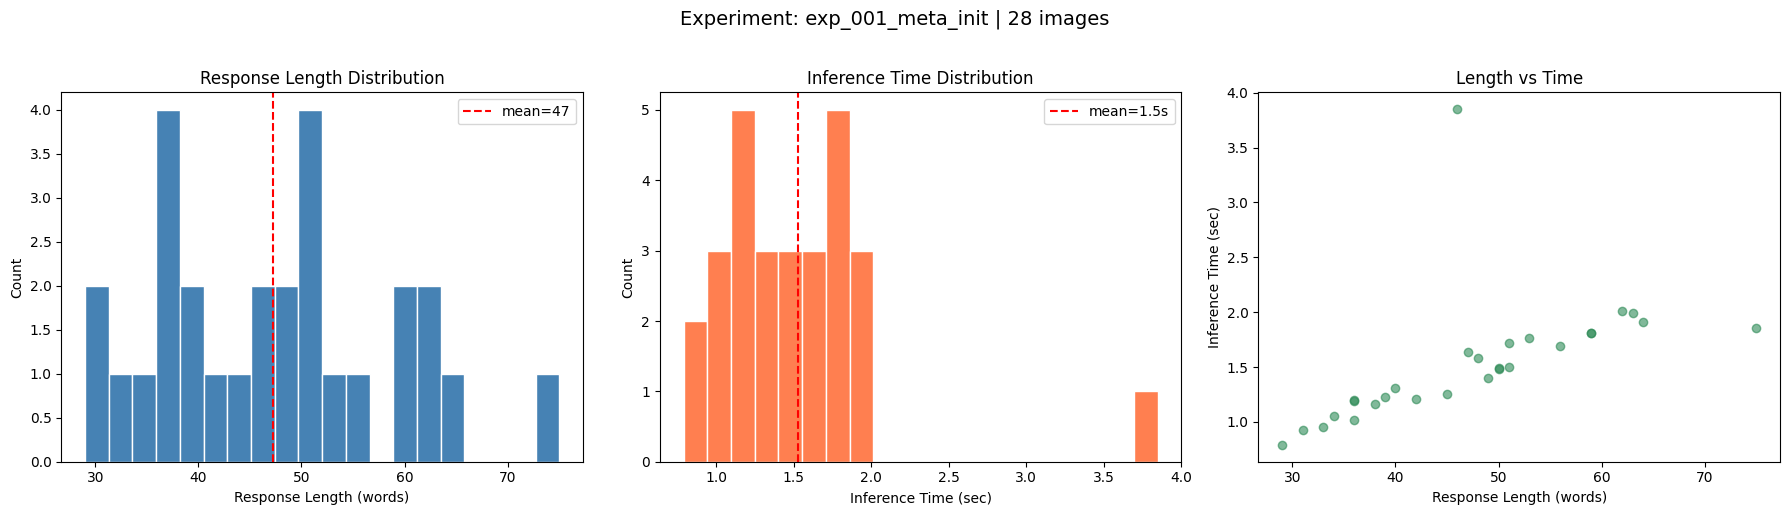

Plot saved to outputs/exp_001_meta_init/stats_20260309_230910.png


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 응답 단어 수 분포
axes[0].hist(df_results["n_words"], bins=20, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Response Length (words)")
axes[0].set_ylabel("Count")
axes[0].set_title("Response Length Distribution")
axes[0].axvline(df_results["n_words"].mean(), color="red", linestyle="--", label=f'mean={df_results["n_words"].mean():.0f}')
axes[0].legend()

# 추론 시간 분포
axes[1].hist(df_results["time_sec"], bins=20, color="coral", edgecolor="white")
axes[1].set_xlabel("Inference Time (sec)")
axes[1].set_ylabel("Count")
axes[1].set_title("Inference Time Distribution")
axes[1].axvline(df_results["time_sec"].mean(), color="red", linestyle="--", label=f'mean={df_results["time_sec"].mean():.1f}s')
axes[1].legend()

# 단어 수 vs 추론 시간
axes[2].scatter(df_results["n_words"], df_results["time_sec"], alpha=0.6, color="seagreen")
axes[2].set_xlabel("Response Length (words)")
axes[2].set_ylabel("Inference Time (sec)")
axes[2].set_title("Length vs Time")

plt.suptitle(f"Experiment: {EXPERIMENT_NAME} | {len(df_results)} images", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"stats_{timestamp}.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved to {OUTPUT_DIR}/stats_{timestamp}.png")

## 10. Biomarker 키워드 매칭 분석

모델 응답에서 주요 OCT biomarker 키워드가 얼마나 감지되었는지 분석합니다.

In [11]:
from collections import Counter

# 주요 OCT biomarker 키워드
BIOMARKERS = [
    "drusen", "fluid", "subretinal fluid", "intraretinal fluid",
    "PED", "pigment epithelial detachment",
    "atrophy", "geographic atrophy", "RPE atrophy",
    "SHRM", "subretinal hyperreflective material",
    "ERM", "epiretinal membrane",
    "edema", "macular edema", "cystoid",
    "CNV", "choroidal neovascularization",
    "hypertransmission",
    "AMD", "age-related macular degeneration",
    "DME", "diabetic macular edema",
]

DIAGNOSES = [
    "wet AMD", "dry AMD", "nAMD", "neovascular AMD",
    "diabetic retinopathy", "DME",
    "macular hole", "vitreomacular traction",
    "central serous", "CSC",
    "retinal vein occlusion", "RVO",
    "normal", "healthy",
]

def extract_keywords(text, keyword_list):
    found = []
    text_lower = text.lower()
    for kw in keyword_list:
        if kw.lower() in text_lower:
            found.append(kw)
    return found

# 각 응답에서 키워드 추출
biomarker_counts = Counter()
diagnosis_counts = Counter()

for r in results:
    resp = r["response"]
    bm = extract_keywords(resp, BIOMARKERS)
    dx = extract_keywords(resp, DIAGNOSES)
    r["biomarkers_found"] = bm
    r["diagnoses_found"] = dx
    for b in bm:
        biomarker_counts[b] += 1
    for d in dx:
        diagnosis_counts[d] += 1

# 요약
print("=" * 50)
print("Biomarker Detection Summary")
print("=" * 50)
for kw, cnt in biomarker_counts.most_common():
    pct = cnt / len(results) * 100
    print(f"  {kw:<40s} {cnt:>3d}/{len(results)} ({pct:.0f}%)")

print(f"\n{'=' * 50}")
print("Diagnosis Summary")
print("=" * 50)
for kw, cnt in diagnosis_counts.most_common():
    pct = cnt / len(results) * 100
    print(f"  {kw:<40s} {cnt:>3d}/{len(results)} ({pct:.0f}%)")

avg_bm = np.mean([len(r["biomarkers_found"]) for r in results])
print(f"\nAvg biomarkers per image: {avg_bm:.1f}")

Biomarker Detection Summary
  fluid                                     28/28 (100%)
  atrophy                                   25/28 (89%)
  drusen                                    20/28 (71%)
  AMD                                       20/28 (71%)
  intraretinal fluid                        17/28 (61%)
  subretinal fluid                          15/28 (54%)
  hypertransmission                         11/28 (39%)
  RPE atrophy                                9/28 (32%)
  subretinal hyperreflective material        7/28 (25%)
  PED                                        5/28 (18%)
  SHRM                                       5/28 (18%)
  ERM                                        2/28 (7%)
  age-related macular degeneration           1/28 (4%)

Diagnosis Summary
  wet AMD                                   12/28 (43%)
  normal                                     3/28 (11%)
  healthy                                    3/28 (11%)
  dry AMD                                    2/28 (7%)

Av

## 11. Biomarker Heatmap 시각화

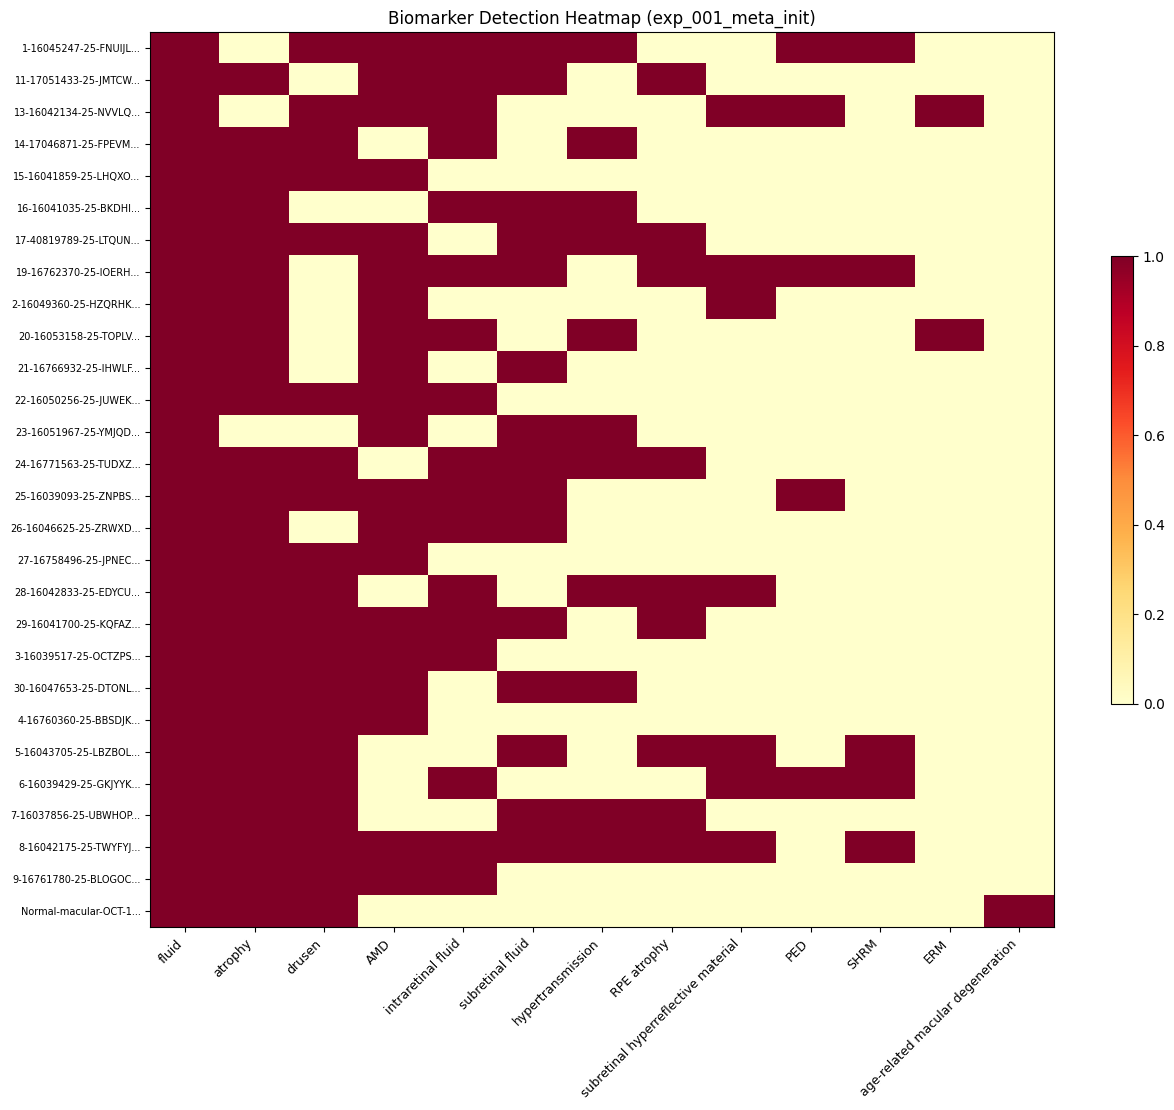

In [12]:
# Biomarker detection heatmap (이미지 x biomarker)
detected_bm = [kw for kw, _ in biomarker_counts.most_common() if biomarker_counts[kw] > 0]

if detected_bm:
    heatmap_data = []
    img_labels = []
    for r in results:
        row = [1 if kw in r["biomarkers_found"] else 0 for kw in detected_bm]
        heatmap_data.append(row)
        img_labels.append(r["image"][:20] + "...")

    heatmap_arr = np.array(heatmap_data)

    fig, ax = plt.subplots(figsize=(max(10, len(detected_bm)), max(6, len(results) * 0.4)))
    im = ax.imshow(heatmap_arr, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(detected_bm)))
    ax.set_xticklabels(detected_bm, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(img_labels)))
    ax.set_yticklabels(img_labels, fontsize=7)
    ax.set_title(f"Biomarker Detection Heatmap ({EXPERIMENT_NAME})")
    plt.colorbar(im, ax=ax, shrink=0.5)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"biomarker_heatmap_{timestamp}.png"), dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No biomarkers detected in any response.")

## 12. 개별 결과 확인

특정 이미지의 OCT 스캔과 모델 응답을 나란히 확인합니다.

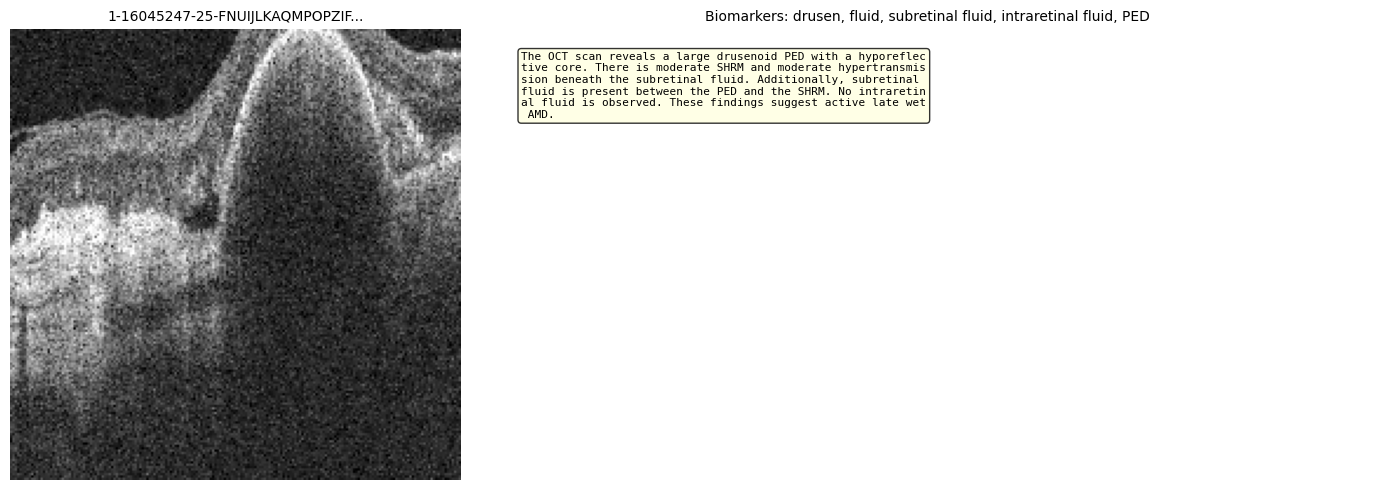

Time: 3.85s | Words: 46 | Diagnoses: ['wet AMD']
----------------------------------------------------------------------


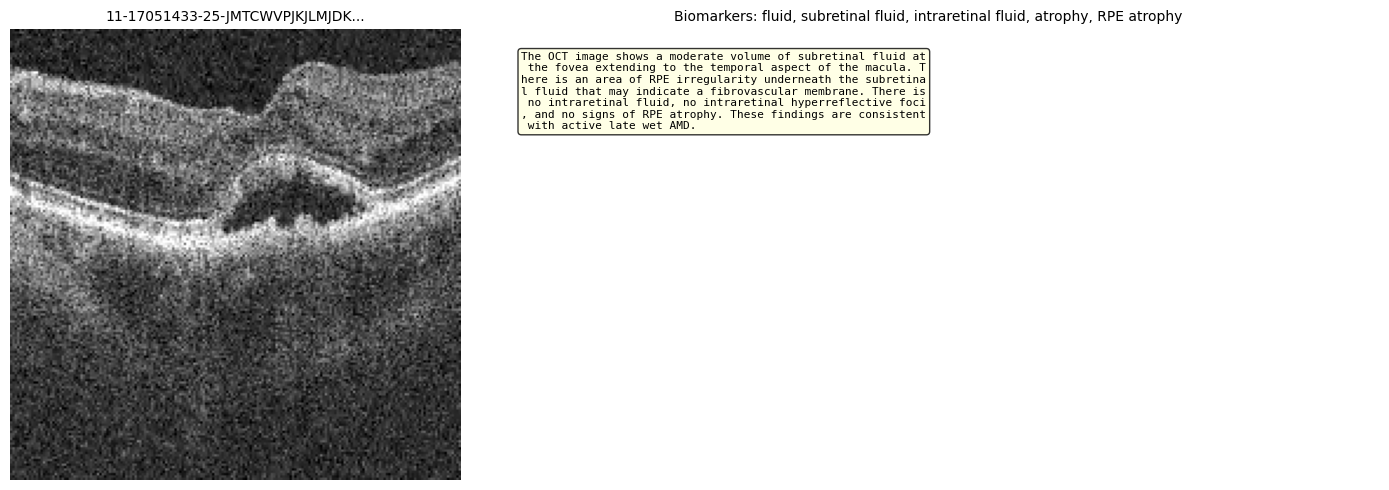

Time: 2.01s | Words: 62 | Diagnoses: ['wet AMD']
----------------------------------------------------------------------


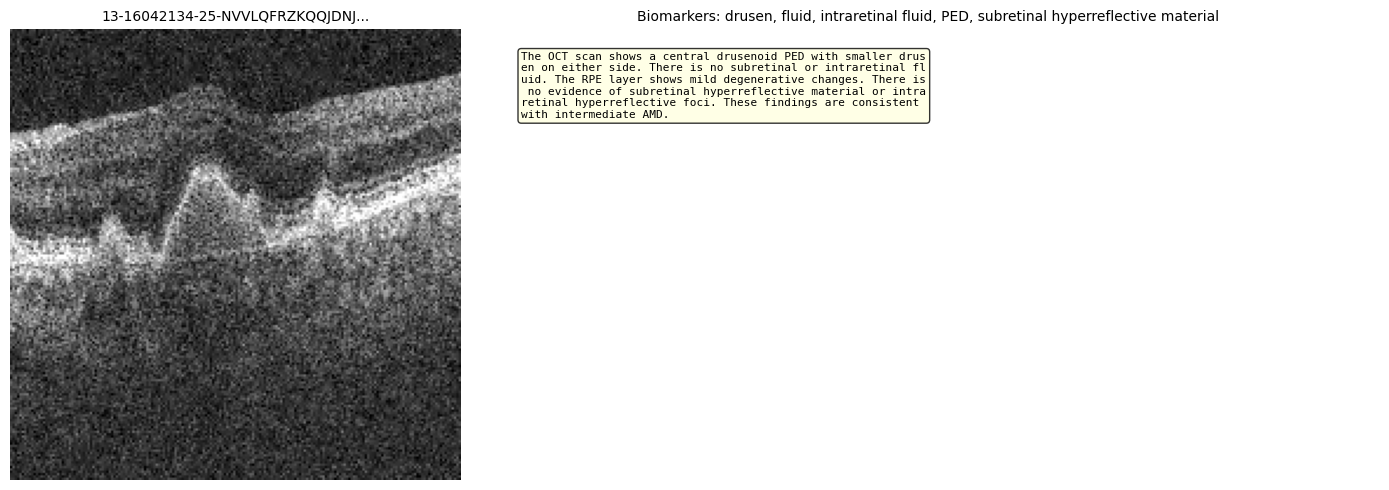

Time: 1.64s | Words: 47 | Diagnoses: []
----------------------------------------------------------------------


In [13]:
def show_result(idx):
    """idx번째 결과를 이미지 + 응답으로 표시"""
    r = results[idx]
    img = Image.open(os.path.join(IMAGE_DIR, r["image"])).convert("L")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1, 2]})

    ax1.imshow(np.array(img), cmap="gray")
    ax1.set_title(r["image"][:30] + "...", fontsize=10)
    ax1.axis("off")

    # 텍스트 표시
    response_text = r["response"]
    wrapped = "\n".join([response_text[i:i+60] for i in range(0, len(response_text), 60)])
    ax2.text(0.05, 0.95, wrapped, transform=ax2.transAxes,
             fontsize=8, verticalalignment="top", fontfamily="monospace",
             bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8))
    ax2.set_title(f"Biomarkers: {', '.join(r.get('biomarkers_found', [])[:5])}", fontsize=10)
    ax2.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"Time: {r['time_sec']}s | Words: {r['n_words']} | Diagnoses: {r.get('diagnoses_found', [])}")

# 첫 3개 결과 확인
for i in range(min(3, len(results))):
    show_result(i)
    print("-" * 70)

## 13. 쿼리 비교 실험 (선택)

여러 쿼리 타입으로 동일 이미지에 대해 응답을 비교합니다.

In [14]:
# 첫 번째 이미지로 모든 쿼리 비교
test_image_path = image_files[0]
test_image = np.array(Image.open(test_image_path).convert('L'))

print(f"Image: {os.path.basename(test_image_path)}")
print("=" * 70)

comparison_results = {}
for qname, qtext in QUERIES.items():
    start = time.time()
    with torch.no_grad():
        out = model.forward([test_image], [qtext], max_new_tokens=MAX_NEW_TOKENS)
    elapsed = time.time() - start
    comparison_results[qname] = {"response": out[0], "time": elapsed}

    print(f"\n[{qname}] ({elapsed:.1f}s)")
    print(f"Q: {qtext[:80]}...")
    print(f"A: {out[0]}")
    print("-" * 70)

# 비교 결과 저장
comp_path = os.path.join(OUTPUT_DIR, f"query_comparison_{timestamp}.json")
with open(comp_path, "w", encoding="utf-8") as f:
    json.dump({
        "image": os.path.basename(test_image_path),
        "comparisons": {k: v for k, v in comparison_results.items()}
    }, f, ensure_ascii=False, indent=2)
print(f"\nComparison saved: {comp_path}")

/home/ubuntu/bionexus/jgy/OCT_LLM_XAI/SpecialistVLMs/models/mini_gpt4.py:167: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return torch.cuda.amp.autocast(dtype=dtype)
Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.


Image: 1-16045247-25-FNUIJLKAQMPOPZIFPBDWMNIKO+XKIVNLSMJGTAWALNGKBBPCEUAIVZAMYGBVJTB+KVGBEV.png
Inputs torch.Size([1, 112, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



[report] (1.5s)
Q: Write a detailed clinical report describing this OCT scan. Identify any visible ...
A: The OCT scan reveals a large drusenoid PED with a hyporeflective core. There is moderate SHRM and moderate hypertransmission beneath the subretinal fluid. Additionally, subretinal fluid is present between the PED and the SHRM. No intraretinal fluid is observed. These findings suggest active late wet AMD.
----------------------------------------------------------------------
Inputs torch.Size([1, 105, 4096])


Setting `pad_token_id` to `eos_token_id`:128009 for open-end generation.



[biomarker] (1.1s)
Q: List all visible biomarkers in this OCT image and their severity (mild, moderate...
A: The image shows a large drusenoid PED with a hyporeflective core, moderate SHRM, moderate hypertransmission beneath the SHRM, subretinal fluid between the PED and the SHRM, and intraretinal fluid.
----------------------------------------------------------------------
Inputs torch.Size([1, 101, 4096])

[diagnosis] (1.4s)
Q: Based on this OCT scan, what is the most likely diagnosis? Provide reasoning....
A: The most likely diagnosis is late wet AMD. This is due to the presence of a large drusenoid PED with a hyporeflective core, moderate SHRM, moderate hypertransmission beneath the SHRM, subretinal fluid between the PED and the SHRM, and intraretinal fluid.
----------------------------------------------------------------------

Comparison saved: outputs/exp_001_meta_init/query_comparison_20260309_230910.json
